# Project 1: Titanic Dataset

In [54]:
# Step 1: Import Libraries and Load Dataset
# Dataset Column Means:
# • PassengerId: Unique numeric identifier for each passenger.
# • Survived: Survival indicator (1 = survived, 0 = did not survive).
# • Pclass: Ticket class representing socio‑economic status (1st, 2nd, or 3rd class).
# • Name: Full name of the passenger, often including title.
# • Sex: Passenger’s gender.
# • Age: Passenger’s age in years (may contain missing values).
# • SibSp: Number of siblings or spouses traveling with the passenger.
# • Parch: Number of parents or children traveling with the passenger.
# • Ticket: Ticket number or code assigned to the passenger.
# • Fare: Amount of money paid for the ticket.
# • Cabin: Cabin number(s), often missing for many passengers.
# • Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

import pandas as pd
import numpy as np

df = pd.read_csv('../../../../../0-Dataset_And_Playground/1-AI-Dataset/titanic.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [55]:
# Show Some Data
df.head(n=5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
# Step 2: Check for Duplicate Rows
# df.duplicated(): Returns a boolean Series indicating duplicate rows.
# or check duplicated with other way: df.duplicated().value_counts() or ( duplicates.sum() & (~duplicates).sum())

# Form 1
# df.duplicated()

# Form 2
df.duplicated().value_counts()

# Form 3
# duplicates = df.duplicated()
# true_count = duplicates.sum()
# false_count = (~duplicates).sum()
# print("True:", true_count)
# print("False:", false_count)


False    891
Name: count, dtype: int64

In [57]:
# Step 3: Identify Column Data Types
# - List comprehension with .dtype attribute to separate categorical and numerical columns.
# - object dtype: Generally used for text or categorical data.

# Form 1
# cat_col = [col for col in df.columns if df[col].dtype == 'object']
# num_col = [col for col in df.columns if df[col].dtype != 'object']
# print('Categorical columns:', cat_col)
# print('Numerical columns:', num_col)

# Form 2 (BEST)
cat_col = df.select_dtypes(include=['object', 'category']).columns
num_col = df.select_dtypes(include=['number']).columns
print('Categorical columns:', list(cat_col))
print('Numerical columns:', list(num_col))

# Form 3
# cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
# num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
# print('Categorical columns:', list(cat_cols))
# print('Numerical columns:', list(num_cols))

# Form 4
# num_cols = df.select_dtypes(include='number').columns.tolist()
# cat_cols = df.select_dtypes(exclude='number').columns.tolist()
# print('Categorical columns:', list(cat_cols))
# print('Numerical columns:', list(num_cols))

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [58]:
# Step 4: Count Unique Values in the Categorical Columns
# - df[cat_col].nunique(): Returns count of unique values per column.

df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [69]:
# Step 5: Calculate Missing Values as Percentage
# - df.isnull(): Detects missing values, returning boolean DataFrame.
# - Sum missing across columns, normalize by total rows and multiply by 100.

# Form 1
# df.isnull() # return dataframe with true or false
# df.isnull().sum()

# Form 2 (normalize - convert to percent)
round((df.isnull().sum() / df.shape[0]) * 100, 2) # df.shape -> (rows, columns) so shape[0] means rows


PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [67]:
# Step 6: Drop Irrelevant or Data-Heavy Missing Columns
# - df.drop(columns=[]): Drops specified columns from the DataFrame.
# - df.dropna(subset=[]): Removes rows where specified columns have missing values.
# - fillna(): Fills missing values with specified value (e.g., mean).

# Create New DF: df1
df1 = df.drop(columns=['Name', 'Ticket', 'Cabin']) # Drop These Column: Name, Ticket, Cabin
df1.dropna(subset=['Embarked'], inplace=True) # Remove Embarked Row That Have NON Value
df1['Age'] = df1['Age'].fillna(df1['Age'].mean()) # Fill Missing Age With Mean In All Row

round((df1.isnull().sum() / df1.shape[0]) * 100, 2) # df.shape -> (rows, columns) so shape[0] means rows

PassengerId    0.0
Survived       0.0
Pclass         0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Fare           0.0
Embarked       0.0
dtype: float64

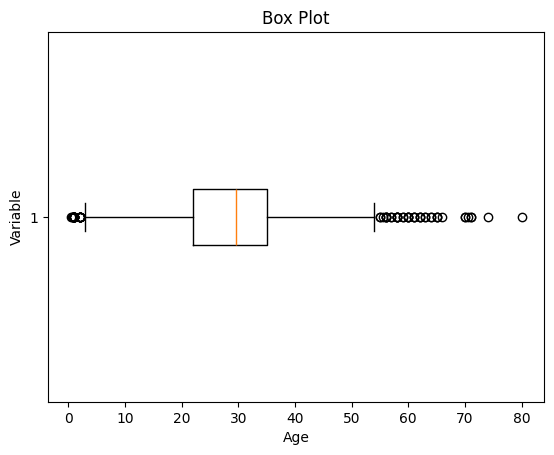

In [71]:
# Step 7: Detect Outliers with Box Plot
# - matplotlib.pyplot.boxplot(): Displays distribution of data, highlighting median, quartiles and outliers.
# - plt.show(): Renders the plot.

import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert=False) # vert=False Means: Draw Horizontal
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

# ---------------- Analysis Notes ----------------

# Box shows middle 50% of data (Q1 to Q3)
# Median = center line inside the box
# IQR = Q3 - Q1

# Whiskers extend to:
# Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Points outside this range are Outliers

# For Age:
# Q1 ≈ 22
# Median ≈ 28–29
# Q3 ≈ 35–36
# IQR ≈ 14

# Upper bound ≈ 57 → values > 57 are outliers

# Distribution is right-skewed because:
# - Right whisker is longer
# - More high-value outliers (60–80)
# - Median slightly closer to Q1 than Q3

# Conclusion:
# Most ages are between ~22–36
# Few elderly values pull distribution to the right

In [73]:
# Step 8: Calculate Outlier Boundaries and Remove Them
# - Calculate mean and standard deviation (std) using df['Age'].mean() and df['Age'].std().
# - Define bounds as mean ± 2 * std for outlier detection.
# - Filter DataFrame rows within bounds using Boolean indexing.

# Calculate mean and standard deviation of Age
mean = df1['Age'].mean()
std = df1['Age'].std()

# Show basic statistics
print("Mean:", mean)                     # Average age ≈ 29.64
print("Standard Deviation:", std)        # Typical spread of ages ≈ 12.97

# Define outlier boundaries using the empirical rule (~95% within ±2 std) (According to Gaussian Distribution)
lower_bound = mean - 2 * std            # ≈ 3.71 → very low ages below this are outliers
upper_bound = mean + 2 * std            # ≈ 55.58 → very high ages above this are outliers

print("lower_bound:", lower_bound)       # Lower limit for normal ages
print("upper_bound:", upper_bound)       # Upper limit for normal ages

# Create New Dataframe(df2)
# Keep only rows where Age is within [lower_bound, upper_bound]
# Ages outside this interval are treated as outliers and removed
df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

# Optional: check how many rows were kept vs removed
print("Original rows:", len(df1))
print("Rows after outlier removal:", len(df2))

Mean: 29.642092696629216
Standard Deviation: 12.968346294351779
lower_bound: 3.7054001079256587
upper_bound: 55.57878528533277
Original rows: 889
Rows after outlier removal: 821


In [74]:
# Step 9: Impute Missing Data Again if Any
# - fillna() applied again on filtered data to handle any remaining missing values.
# Why? removing outliers will create new changes.

# Create New Dataframe: df3
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [64]:
# Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data
# - mean = df3['Age'].mean(): Calculates the average (mean) value of the Age column in the DataFrame df3.
# - std = df3['Age'].std(): Computes the standard deviation (spread or variability) of the Age column in df3.
# - lower_bound = mean - 2 * std: Defines the lower limit for acceptable Age values, set as two standard deviations below the mean.
# - upper_bound = mean + 2 * std: Defines the upper limit for acceptable Age values, set as two standard deviations above the mean.
# - df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]: Creates a new DataFrame df4 by selecting only rows where the Age value falls between the lower and upper bounds, effectively removing outlier ages outside this range.

mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.978989004171453
Upper Bound : 49.30395961288914


In [65]:
# Step 11: Data validation and verification
# Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge
# - For the machine learning prediction we separate independent and target features
# - Here we will consider only 'Sex' 'Age' 'SibSp', 'Parch' 'Fare' 'Embarked' only as the independent features
# - Survived as target variables because PassengerId will not affect the survival rate

X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']

In [66]:
# Step 12: Data formatting
# Data formatting involves converting the data into a standard format or structure that can be easily processed by the algorithms or models used for analysis. Here we will discuss commonly used data formatting techniques i.e. Scaling and Normalization.

# 1. Min-Max Scaling: Scaling involves transforming the values of features to a specific range. Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

# 2. Standardization (Z-score scaling): Standardization transforms the values to have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it based on the standard deviation. Standardization makes the data more suitable for algorithms that assume a Gaussian distribution or require features to have zero mean and unit variance.
# Z = (X - μ) / σ
# Where,
# X = Data
# μ = Mean value of X
# σ = Standard deviation of X

C:\Users\sepehr\AppData\Local\Temp\ipykernel_13368\3467147035.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1[num_col_] = scaler.fit_transform(x1[num_col_])


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S
